## Revisiting the LSTM

In [1]:
### importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### importing the key
load_dotenv('../keys.txt')
key = os.getenv('key')

### Defining the functions and working with them

In [3]:
### targeting only the features ['close', 'high', 'low' and 'open']
features_to_target = ['close', 'high', 'low', 'open']

In [4]:
### function to load the stock price
def load_stock_price(symbol, features_to_target) : 

    df = pdr.get_data_tiingo(symbol, api_key = key)
    df = df[features_to_target].reset_index(drop = True)

    return df

In [5]:
stock_boeing = load_stock_price('BA', features_to_target)
stock_boeing.tail()

,close,high,low,open
1250,232.44,236.450,232.065000,234.99
1251,231.33,235.450,229.390000,233.00
1252,230.72,231.330,227.070000,231.05
1253,224.11,230.255,221.150000,230.22
1254,229.03,229.550,224.612027,225.90


In [6]:
stock_apple = load_stock_price('AAPL', features_to_target)
stock_apple.tail()

,close,high,low,open
1250,271.06,273.06,269.65,272.755
1251,267.61,268.36,265.07,266.090
1252,270.71,273.23,268.66,272.335
1253,270.17,271.04,267.04,267.550
1254,271.35,276.00,268.14,270.500


In [45]:
### function to plot the graphs for the scaled and non scaled data as the comparison
def plot_graphs(df, df_scaled = None) : 

    if df_scaled is not None : 

        for column in df.columns : 
                
            plt.figure(figsize = (8, 4))
            plt.subplot(1, 2, 1)
            plt.title(f"Before scaling :  {column}")
            plt.plot(df[column])
            plt.subplot(1, 2, 2)
            plt.title(f"After scaling :  {column}")
            plt.plot(df_scaled[column])


    else : 
        
        for column in df.columns : 
            plt.figure(figsize = (6, 4))
            plt.title(column)
            plt.plot(df[column])

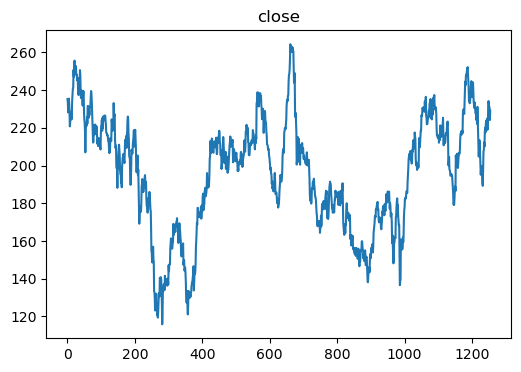

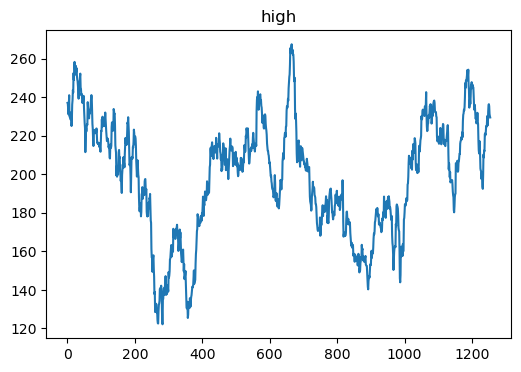

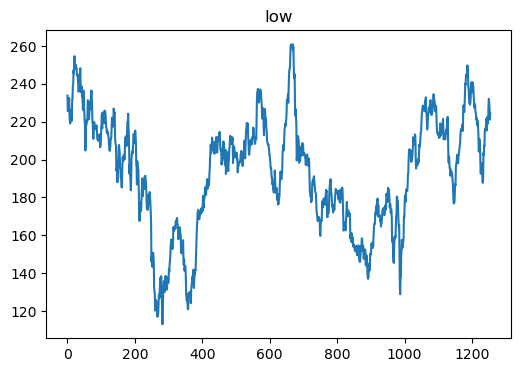

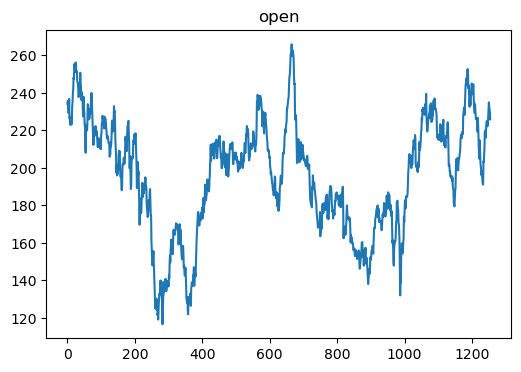

In [46]:
### plotting the graphs for the 'stock_boeing'
plot_graphs(stock_boeing)

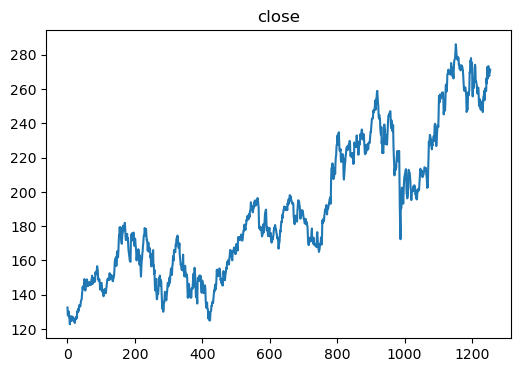

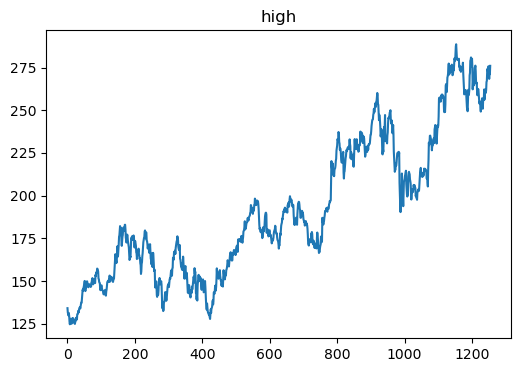

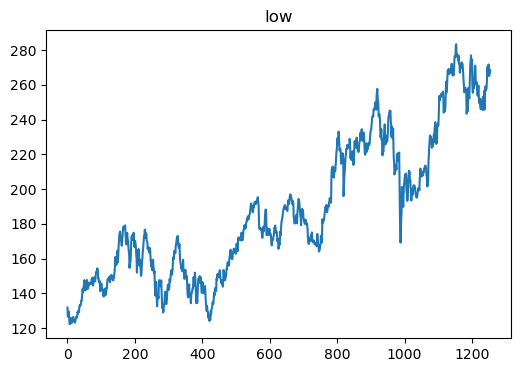

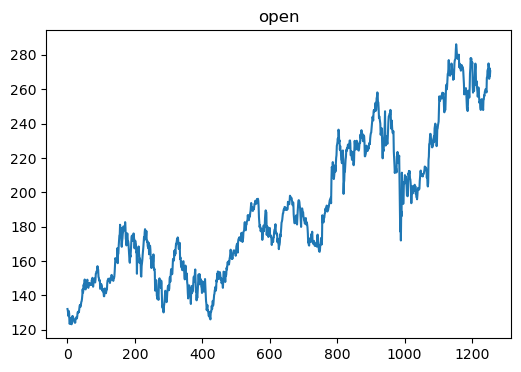

In [47]:
### plotting the graphs for the 'stock_apple'
plot_graphs(stock_apple)

In [38]:
### function to scale the data
def scale_data(df, scaler) : 

    df_scaled = scaler.fit_transform(df)
    df_scaled = pd.DataFrame(df_scaled, columns = df.columns)

    return df_scaled

In [48]:
### loading the scaler from the library
from sklearn.preprocessing import MinMaxScaler
scaler_apple = MinMaxScaler(feature_range = (0, 1))
scaler_boeing = MinMaxScaler(feature_range = (0, 1))

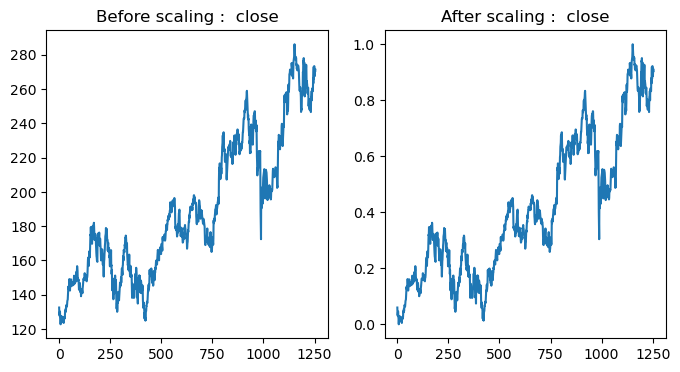

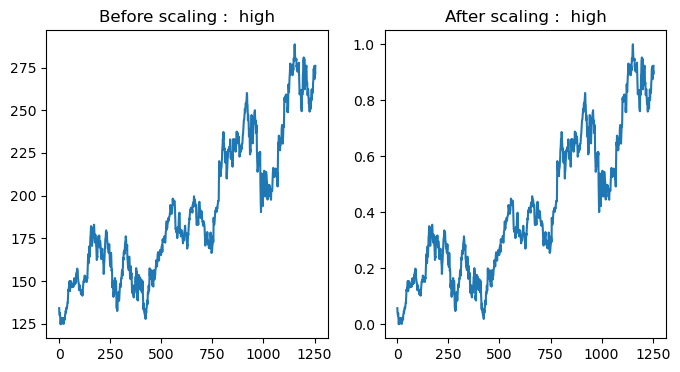

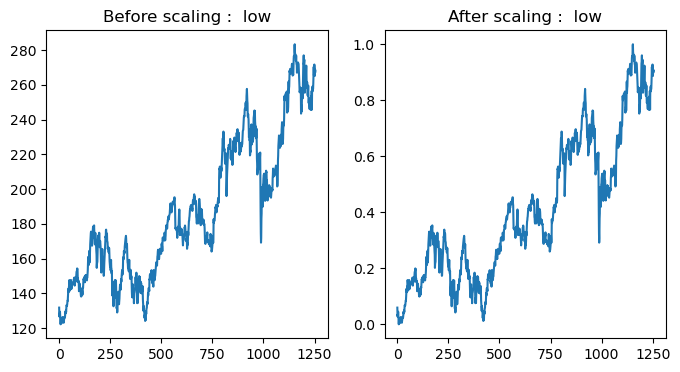

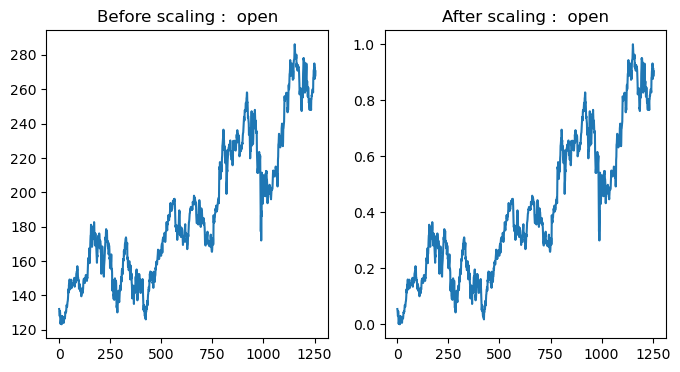

In [ ]:
### scaling the data 'stock_apple' and the graphs for the comparison
stock_apple_scaled = scale_data(stock_apple, scaler = scaler_apple)
plot_graphs(stock_apple, stock_apple_scaled)

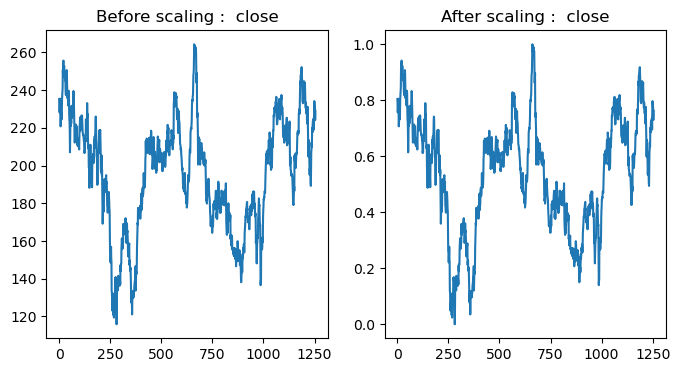

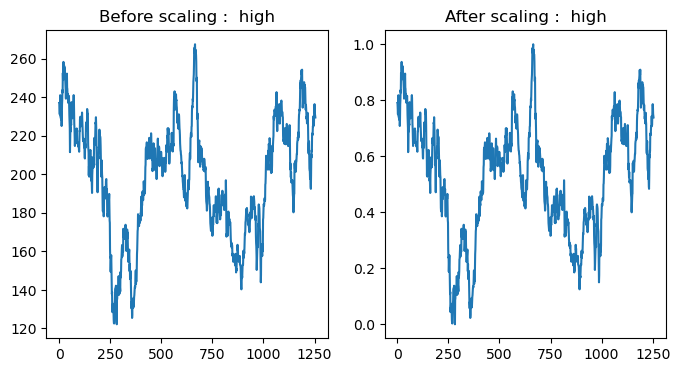

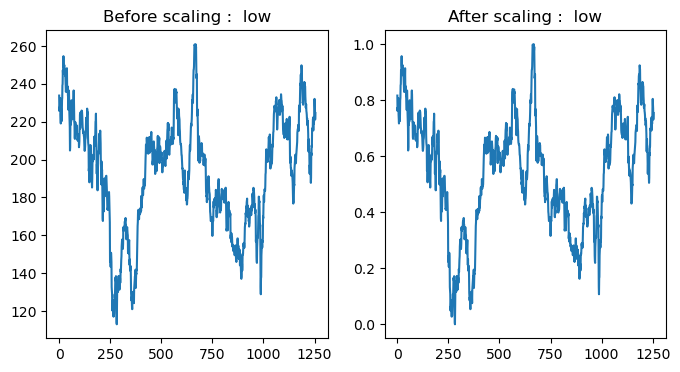

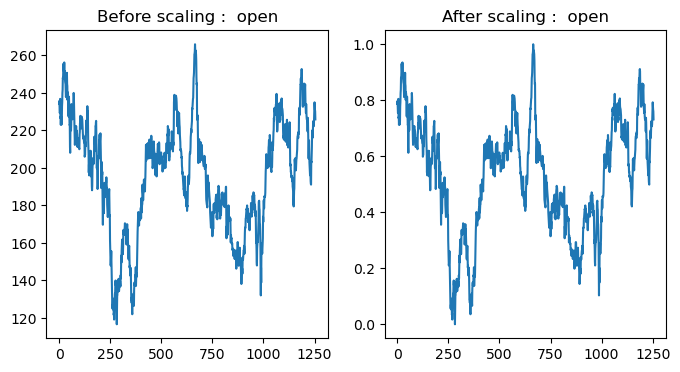

In [51]:
### scaling the data 'stock_boeing' and the graphs for the comparison
stock_boeing_scaled = scale_data(stock_boeing, scaler = scaler_boeing)
plot_graphs(stock_boeing, stock_boeing_scaled)